### Experiments and code related to PPCA part of the algorithm

#### Issues

- Not getting orthonormal columns in V

In [1]:
# Adjust import path
import sys
sys.path.append("../things")
sys.path.append("../")

import os
import h5py
import numpy as np

import opinf

import config
import utils
import step1_generate_data as step1

import matplotlib.pyplot as plt
from ppca_jax import BayesianPPCA
import jax.numpy as jnp
import jax

Logging to log.log


#### Generate Noisy Data

In [2]:
training_span = (0, 6) # (0, 6)
num_samples= 400 # 400
noiselevel= .0 # 0
num_regression_points= 400 # 400
numPODmodes= 3 # 3
gp_regularizer= 1e-4 # 1e-4
ndraws=100 # 100
exportto=None
openonsave=False
ddtdata=False

config.time_domain = np.linspace(0, 8, 801)  # Temporal domain t.

In [3]:
if isinstance(numPODmodes, (list, tuple)) and len(numPODmodes) == 1:
    numPODmodes = numPODmodes[0]

# Report on experimental scenario.
utils.summarize_experiment(
    training_span=training_span,
    num_samples=num_samples,
    noiselevel=noiselevel,
    num_regression_points=num_regression_points,
    numPODmodes=numPODmodes,
    gp_regularizer=gp_regularizer,
    ndraws=ndraws,
)

# Step 1: Generate data ---------------------------------------------------
(
    model,
    time_domain,
    true_states,
    time_domain_sampled,
    snapshots_sampled,
) = step1.trajectory(training_span, num_samples, config, noiselevel)

time_domain_training = np.linspace(
    training_span[0],
    training_span[-1],
    num_regression_points,
)


EXPERIMENTAL SCENARIO
Data: 400 uniformly sampled snapshots over 0.00 ≤ t < 6.00 with 0.00% noise
Dimension: retaining 3 POD modes
Training: using 400 regression points
GP regularization: eta = 1.00e-04
Posterior: 100 draws

generating training data...done in 0.38 s.


#### Do a deterministic fit

reducing noisy training states to 3 dimensions...Basis
  full_state_dimension:    None
  reduced_state_dimension: None
  SVD solver: scipy.linalg.svd()
Snapshot sampled shape: (1024, 400)
(512, 400) (512, 400)
(3, 801)
done in 0.05 s.


INFO:2025-06-25 16:26:41,374:jax._src.xla_bridge:752: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/Users/anthonypoole/miniconda3/envs/prob_rom/bin/../lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file)


Weight matrix None
Off diagonal loss -6.9735884e-15


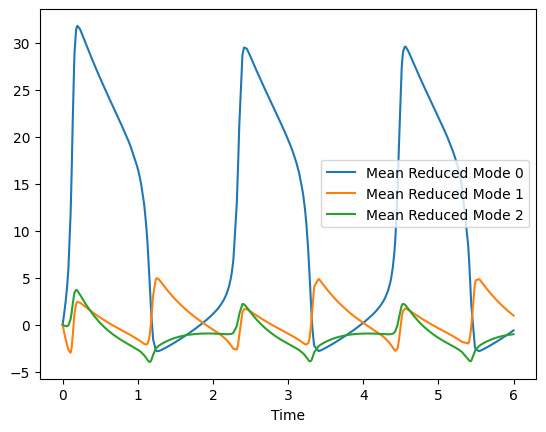

In [4]:
# Dimensionality reduction (POD).
with opinf.utils.TimedBlock(
    f"reducing noisy training states to {numPODmodes} dimensions"
):
    basis = config.Basis(num_vectors=numPODmodes)
    print(basis)
    print(f"Snapshot sampled shape: {snapshots_sampled.shape}")
    basis.fit(snapshots_sampled)
    # print(f"{}")
    snapshots_compressed = basis.compress(snapshots_sampled)
    full_states_compressed = basis.compress(true_states)
    print(full_states_compressed.shape)

V = basis.entries
W = basis.weights
print(f'Weight matrix', W)

off_diagonal_loss = jnp.sum((V.T @ V) - jnp.eye(V.shape[1])**2)
print("Off diagonal loss", off_diagonal_loss)

for i in range(numPODmodes):
    plt.plot(time_domain_sampled, snapshots_compressed[i], label = f"Mean Reduced Mode {i}")
plt.xlabel('Time')
plt.legend()

#### Fit probabilistic PCA

In [ ]:

class LiftedPPCA(BayesianPPCA):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
    
    def transform(self, states):
        q1, q2 = jnp.split(states, 2, axis=0)
        return jnp.concatenate([q1, q2, q1**2])
    
    def compress(self, states):
        super().compress(self.transform(states))
    
    def decompress(self, states):
        decompressed_states = super().decompress(states)
        q1, q2, _ = jnp.split(decompressed_states, 3, axis=0)
        return jnp.concatenate([q1,q2])
    
    def fit(self,states, num_samples, warmup_steps, rng_key, penalty):
        super().fit(self.transform(states), num_samples = num_samples, warmup_steps = warmup_steps, rng_key = rng_key, penalty = penalty)

# Fit Bayesian PPCA
reduced_dim = 3
param_dim, time_dim = snapshots_sampled.shape  # param_dim is what we want to reduce

print("\nFitting Bayesian PPCA...")
ppca = LiftedPPCA(latent_dim=reduced_dim, obs_dim=param_dim)

# Create a random key for JAX
rng_key = jax.random.PRNGKey(42)

# Transpose the data so each time step is a sample
ppca.fit_svi( # Could use svi_fit too
    jnp.array(snapshots_sampled),  # Note the .T here
    # num_samples=500
    # warmup_steps=250,
    rng_key=rng_key,
    penalty = True
)

# Transform the transposed data
compressed_snaps = ppca.transform(jnp.array(snapshots_sampled.T))
print(f"Compressed shape: {compressed_snaps.shape}")  # Should be (time_dim, reduced_dim)

# If you want the result in the original orientation, transpose back
compressed_snaps_original_orientation = compressed_snaps.T
print(f"Original orientation shape: {compressed_snaps_original_orientation.shape}")  # Should be (reduced_dim, time_dim)


Fitting Bayesian PPCA...
Running SVI optimization...


100%|██████████| 5000/5000 [00:09<00:00, 554.81it/s, init loss: 29072924672.0000, avg. loss [4751-5000]: 222045.0156] 


SVI completed. Final loss: 219673.5312
Compressed shape: (600, 1024)
Original orientation shape: (1024, 600)


In [10]:
from opinf.basis import PODBasis

# Show fitting 
# after fit():
post = ppca.get_posterior_mean()
V_mean = np.array(post["V"])            # (obs_dim, latent_dim)

off_diagonal_loss = jnp.sum((V_mean.T @ V_mean) - jnp.eye(V_mean.shape[1])**2)
print("Off diagonal loss", off_diagonal_loss)

# skinny SVD
U, S, _ = np.linalg.svd(V_mean, full_matrices=False)

pod = PODBasis.from_svd(U[:, :numPODmodes], S[:numPODmodes], _[:numPODmodes, :])
# pod.basis_entries = U[:, :numPODmodes]
# pod.singular_values = S[:numPODmodes]
# pod._dimension = numPODmodes

Off diagonal loss -2.3915184


In [11]:
compressed_snaps = pod.compress(snapshots_sampled)
uncompressed_snaps = pod.decompress(compressed_snaps)
compressed_snaps_ppca = ppca.transform(snapshots_sampled.T)
compressed_snaps.shape, compressed_snaps_ppca.shape

((3, 400), (600, 1024))

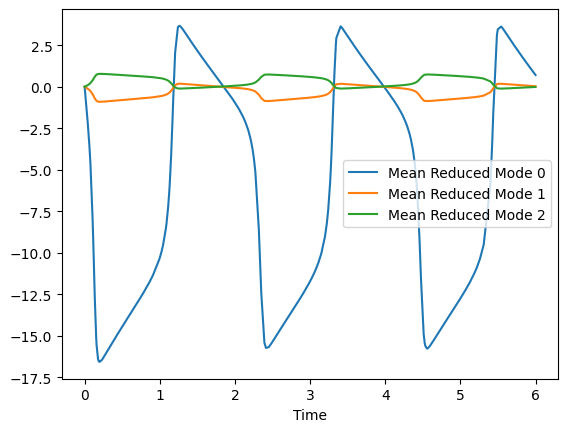

In [12]:
for i in range(numPODmodes):
    plt.plot(time_domain_sampled, compressed_snaps[i], label = f"Mean Reduced Mode {i}")
plt.xlabel('Time')
plt.legend()

ValueError: x and y must have same first dimension, but have shapes (400,) and (600, 1024)

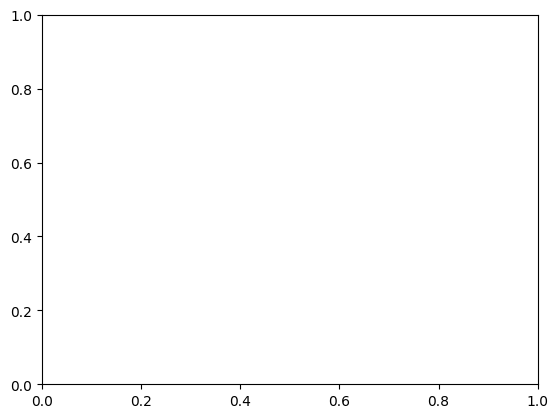

In [13]:
plt.plot(time_domain_sampled, compressed_snaps_ppca)